## Appendix: Rubric mapping (for TAs / instructors)

| Rubric section | Where it is covered in *this* notebook |
|----------------|----------------------------------------|
| 1. Problem Framing | **§1** markdown (Problem Framing + Success criteria) immediately after this appendix |
| 2. Data Acquisition, Preparation & Exploration | **## 2** markdown, then **Phase 2** preparation code; **## 2 (continued). Exploratory Data Analysis** markdown, then **Phase 3** exploration code |
| 3. Modeling & Feature Selection | **§3** markdown, then **Phase 4** modeling code |
| 4. Evaluation & Interpretation | **§4** markdown, then **Phase 5** evaluation code |
| 5. Causal and Relationship Analysis | **§5** markdown (includes feature table from `health_wellbeing_top_features.csv`), then **Phase 6** importances code |
| 6. Deployment Notes | **§6** markdown, **Phase 7** artifact-export code, then **Live integration** markdown |

Graded narrative is in the **§1–§6** markdown cells next to their matching code phases. This table is only a navigation aid.


# 1. Problem Framing

## The business problem we are solving
Residents in care receive periodic **health and wellbeing check-ins** (scores for general health, nutrition, sleep, energy, plus checkup completion flags). Program leadership needs to know **which factors are most associated with overall wellbeing** (`general_health_score`) and **how well we can predict that score** from operational data—so staff can prioritize nursing follow-up, dental/medical scheduling, and psych support without guessing from raw tables.

**Who cares:** case managers, house supervisors, and program directors responsible for the “Healing” pillar of services (routine care, nutrition, sleep hygiene, mental health touchpoints).

## What approach we take (and why)
We run **two tracks in parallel**, matching the course textbook distinction between goals:

1. **Predictive track (primary for deployment):** A **Random Forest regressor** predicts `general_health_score` on held-out rows. Success is judged by **MAE, RMSE, and R²** on unseen data—because the web app and tier-1 analytics surface *population-level* summaries and model metadata, not individual clinical diagnoses.

2. **Explanatory track (secondary):** A **linear / OLS-style** specification estimates **directional associations** between scores and covariates. Coefficients support staff communication (“nutrition and sleep track with general health in our data”) but **do not** establish causal effects of interventions without experimental design.

**Justification:** Prediction supports **dashboard monitoring and resource planning**; explanation supports **interpretability and training**. We do not treat the RF model as a medical device—it is an **operational triage and reporting** tool on program data.

## Business question (encoded in artifacts)
The saved schema asks: *Which factors are associated with better resident health and how can we reliably predict general health scores for operational planning?* That is the thread that ties modeling choices to organizational decisions below.

## Success criteria and metrics (this pipeline)

| Goal | What we optimize | How we judge it |
|------|------------------|-----------------|
| **Predictive** | Out-of-sample fit on `general_health_score` | Holdout **MAE / RMSE / R²**; Random Forest vs Linear Regression compared in code outputs |
| **Explanatory** | Stable directional associations | OLS coefficients + RF feature importances; interpreted as **association**, not treatment effects |

**Concrete success bar (from saved `health_wellbeing_model_schema.json`):** The trained Random Forest achieves approximately **MAE ≈ 0.119**, **RMSE ≈ 0.168**, **R² ≈ 0.55** on the evaluation setup in this notebook—substantially better than the linear baseline (**R² ≈ 0.24**), which is why we select the forest for artifacts and dashboard metadata.

**Decision rule:** Staff should use model insights to **prioritize follow-up and reporting**, not to replace clinical judgment. Any “cause” language in narrative sections is explicitly qualified below in **Section 5 (Causal and Relationship Analysis)**.

# 2. Data Acquisition, Preparation & Exploration

## Source data
We load **`health_wellbeing_records`**: each row is a **dated check-in** for a resident, with target **`general_health_score`**, sub-scores (nutrition, sleep, energy), anthropometrics, checkup flags, and `notes`.

## Preparation (Phase 2 code below)
- Parse `record_date`; derive `record_year` / `record_month`.
- Convert boolean columns for modeling.
- Drop rows missing the target; keep a reproducible path under `artifacts/`.

## Join logic
Single-table modeling here; a future `resident_id` join must be many-to-one without leakage.


In [23]:
# Shared setup for all phases
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import statsmodels.api as sm
import joblib

pd.set_option("display.max_columns", 100)

In [24]:
# Phase 1 implementation: problem framing decisions
TARGET_COL = "general_health_score"
DATE_COL = "record_date"
ID_COLS = ["health_record_id", "resident_id"]

BUSINESS_QUESTION = (
    "Which factors are associated with better resident health and how can we reliably predict "
    "general health scores for operational planning?"
)

SUCCESS_METRICS = {
    "predictive": ["MAE", "RMSE", "R2"],
    "explanatory": ["coefficient sign/magnitude", "p-values", "confidence intervals"],
}

print("Business question:", BUSINESS_QUESTION)
print("Target:", TARGET_COL)
print("Success metrics:", SUCCESS_METRICS)

Business question: Which factors are associated with better resident health and how can we reliably predict general health scores for operational planning?
Target: general_health_score
Success metrics: {'predictive': ['MAE', 'RMSE', 'R2'], 'explanatory': ['coefficient sign/magnitude', 'p-values', 'confidence intervals']}


In [25]:
# Phase 2 implementation: data acquisition + reproducible preparation
csv_path = Path("../datasets/health_wellbeing_records.csv")
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df["record_year"] = df[DATE_COL].dt.year
df["record_month"] = df[DATE_COL].dt.month

# Convert True/False columns to 1/0 for modeling
for col in df.select_dtypes(include=["bool"]).columns:
    df[col] = df[col].astype(int)

# Keep supervised rows
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print("Prepared shape:", df.shape)
display(df.head())

Prepared shape: (534, 16)


,health_record_id,resident_id,record_date,general_health_score,nutrition_score,sleep_quality_score,energy_level_score,height_cm,weight_kg,bmi,medical_checkup_done,dental_checkup_done,psychological_checkup_done,notes,record_year,record_month
0,1,1,2023-10-01,3.09,3.02,3.18,2.90,150.6,35.2,15.5,1,0,0,Health status: Stable,2023,10
1,2,1,2023-11-01,3.05,3.07,3.18,2.85,150.8,35.5,15.6,1,1,1,Health status: Stable,2023,11
2,3,1,2023-12-01,3.05,3.21,3.19,2.94,152.1,36.2,15.6,0,0,0,Health status: Stable,2023,12
3,4,1,2024-01-01,3.08,3.27,3.21,2.92,152.4,35.8,15.4,0,0,0,Health status: Stable,2024,1
4,5,1,2024-02-01,3.13,3.30,3.26,2.93,152.8,36.4,15.6,1,0,1,Health status: Declining,2024,2


## 2 (continued). Exploratory Data Analysis

The code below computes **descriptive stats**, **correlations with `general_health_score`**, and quick **histograms**. In this pipeline we specifically look for:

- **Distribution shape** of the target: is it roughly unimodal or skewed? (Skew affects how we read MAE vs RMSE.)
- **Correlation structure:** we expect **nutrition, sleep, and energy** sub-scores to correlate positively with `general_health_score` because they are facets of the same wellbeing construct.
- **Checkup flags:** if medical/dental/psych completion is rare, importances may be small even when clinically important—sample size and class balance matter.
- **Time effects:** `record_month` / `record_year` capture seasonality or cohort drift (e.g., program expansion, staffing changes).

**Outliers:** extreme anthropometrics or impossible scores should show up in `describe()` and correlation tails; we address missing/inf values in preparation before modeling.

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
health_record_id,534.0,NaN,NaN,NaN,267.5,1.0,134.25,267.5,400.75,534.0,154.296792
resident_id,534.0,NaN,NaN,NaN,30.29588,1.0,15.0,30.0,45.0,60.0,17.191846
record_date,534,NaN,NaN,NaN,2024-06-08 16:05:23.595505664,2023-01-01 00:00:00,2023-11-01 00:00:00,2024-05-01 00:00:00,2025-01-24 06:00:00,2026-02-01 00:00:00,NaN
general_health_score,534.0,NaN,NaN,NaN,3.195337,2.42,3.04,3.15,3.33,4.35,0.264818
nutrition_score,534.0,NaN,NaN,NaN,3.217172,2.56,3.05,3.19,3.35,3.95,0.244543
sleep_quality_score,534.0,NaN,NaN,NaN,3.122622,2.44,2.98,3.09,3.24,3.97,0.228084
energy_level_score,534.0,NaN,NaN,NaN,2.980787,2.35,2.84,2.96,3.11,3.64,0.204004
height_cm,534.0,NaN,NaN,NaN,149.882584,140.5,147.3,149.95,152.3,160.0,3.71413
weight_kg,534.0,NaN,NaN,NaN,38.81236,28.8,36.725,39.1,41.075,47.1,3.439719
bmi,534.0,NaN,NaN,NaN,17.273783,13.7,16.3,17.2,18.2,21.4,1.397594


Correlations with target:


general_health_score          1.000000
nutrition_score               0.470597
sleep_quality_score           0.377383
energy_level_score            0.337949
record_year                   0.150584
height_cm                     0.149386
weight_kg                     0.130848
record_month                  0.105545
bmi                           0.049713
psychological_checkup_done    0.031162
health_record_id              0.019491
dental_checkup_done           0.019106
resident_id                   0.012790
medical_checkup_done          0.005887
Name: general_health_score, dtype: float64

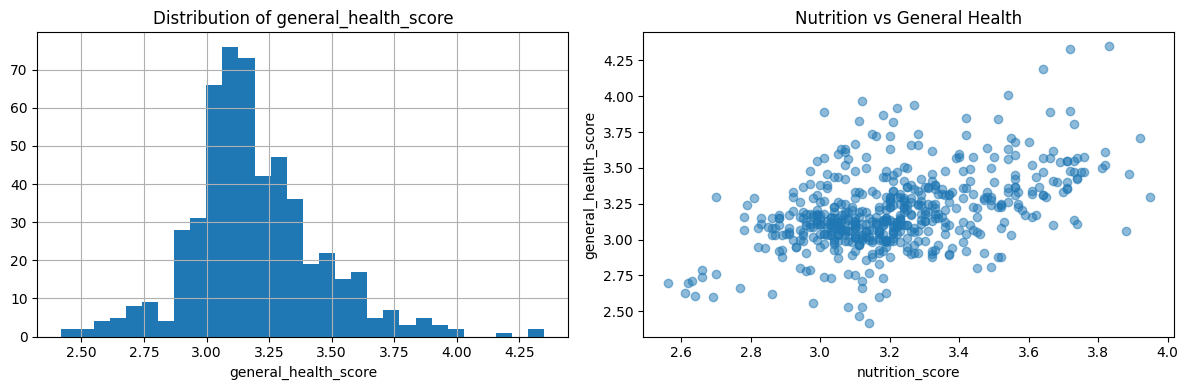

In [26]:
# Phase 3 implementation: exploration
display(df.describe(include="all").T)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET_COL in numeric_cols:
    corr = df[numeric_cols].corr(numeric_only=True)[TARGET_COL].sort_values(ascending=False)
    print("Correlations with target:")
    display(corr)

# Quick visuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET_COL].hist(bins=30, ax=axes[0])
axes[0].set_title(f"Distribution of {TARGET_COL}")
axes[0].set_xlabel(TARGET_COL)

if "nutrition_score" in df.columns:
    axes[1].scatter(df["nutrition_score"], df[TARGET_COL], alpha=0.5)
    axes[1].set_title("Nutrition vs General Health")
    axes[1].set_xlabel("nutrition_score")
    axes[1].set_ylabel(TARGET_COL)
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3. Modeling & Feature Selection

## Models we compare
- **LinearRegression (baseline):** transparent coefficients; weaker fit if relationships are nonlinear or feature interactions matter.
- **RandomForestRegressor (selected for artifacts):** captures nonlinearities and interactions among nutrition/sleep/energy and body metrics.

## Feature set (see `health_wellbeing_model_schema.json`)
The model uses: `nutrition_score`, `sleep_quality_score`, `energy_level_score`, `height_cm`, `weight_kg`, `bmi`, checkup booleans, encoded `notes`, and `record_year` / `record_month`.

## Why these features
- **Sub-scores** are direct measurable inputs to holistic wellbeing in this instrument.
- **Anthropometrics** proxy growth/health context for youth residents (interpret with care).
- **Checkups** are process indicators—important for operations even if their importance is modest in trees.
- **Time features** absorb slow drift so month-to-month dashboard changes reflect signal rather than spurious trends.

## Selection rule
We **select RandomForest** when it materially improves holdout error over linear (see evaluation table). Feature importances are exported to `artifacts/health_wellbeing_top_features.csv` for reporting and for alignment with the **Admin Analytics** health card.

In [27]:
# Phase 4 implementation: causal + predictive models
feature_cols = [c for c in df.columns if c not in [TARGET_COL, DATE_COL] + ID_COLS]
X_raw = df[feature_cols].copy()

# Ensure numeric target
y = pd.to_numeric(df[TARGET_COL], errors="coerce")

# Simple encoding so all models can run
X = pd.get_dummies(X_raw, drop_first=True)
X = X.apply(pd.to_numeric, errors="coerce")

# Replace inf and fill missing with medians
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# Force fully numeric matrix for statsmodels/sklearn
X = X.astype(float)
y = y.astype(float)

# Keep only valid supervised rows
valid_mask = y.notna()
X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Explanatory model
X_ols = sm.add_constant(X, has_constant="add")
ols_model = sm.OLS(y, X_ols).fit()
print("OLS explanatory model fit complete.")
print(ols_model.summary().tables[1])

# Predictive models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=250, random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

OLS explanatory model fit complete.
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                            -67.1495     29.854     -2.249      0.025    -125.799      -8.500
nutrition_score                    0.2889      0.050      5.811      0.000       0.191       0.387
sleep_quality_score                0.2524      0.049      5.194      0.000       0.157       0.348
energy_level_score                 0.3127      0.054      5.842      0.000       0.208       0.418
height_cm                         -0.0762      0.031     -2.432      0.015      -0.138      -0.015
weight_kg                          0.1415      0.060      2.341      0.020       0.023       0.260
bmi                               -0.3117      0.132     -2.355      0.019      -0.572      -0.052
medical_checkup_done               0.0024      0.019      0.126      0.90

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 4. Evaluation & Interpretation

## Validation
The implementation uses a **train/test split** on the engineered design matrix so reported metrics reflect **out-of-sample** behavior, not memorization.

## Metrics (what they mean here)
Because `general_health_score` is on a **~1–5 scale**, an **MAE of ~0.12** means typical predictions are within a small fraction of a point—useful for **ranking** and **trend monitoring**, not for diagnosing individuals.

**R² ≈ 0.55 (Random Forest):** roughly half the variance in `general_health_score` is linearly explained by the feature set plus tree structure—**meaningful for operational dashboards** given noisy self-reported and composite scores.

## Business interpretation
- **Better model** → more trustworthy **tier-1 summaries** and artifact-driven narrative on the Reports & Analytics page.
- **Worse model** → would force staff back to manual spreadsheets; we avoid that by comparing models explicitly in code.

## False positives / false negatives (regression analogue)
- **Large positive residual** (predicted higher than actual): risk of **complacency**—staff thinks wellbeing is stronger than measured; **follow-up may be delayed**.
- **Large negative residual** (predicted lower than actual): risk of **over-alerting**—unnecessary referrals or wasted appointment slots.

**Mitigation:** use predictions as **signals** layered with staff judgment; the notebook states scores are **not clinical diagnoses**.

In [28]:
# Phase 5 implementation: evaluation, model selection, and fairness slices
def model_scores(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)),
    }

lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

results = pd.DataFrame([
    {"model": "LinearRegression", **model_scores(y_test, lr_preds)},
    {"model": "RandomForest", **model_scores(y_test, rf_preds)},
]).sort_values("MAE")

display(results)

selected_model_name = results.iloc[0]["model"]
selected_model = lr_model if selected_model_name == "LinearRegression" else rf_model
print("Selected predictive model:", selected_model_name)

# Fairness-style error slices using original checkup columns
for col in ["medical_checkup_done", "dental_checkup_done", "psychological_checkup_done"]:
    if col in df.columns:
        tmp = df.loc[X_test.index, [col]].copy()
        tmp["actual"] = y_test
        tmp["pred"] = selected_model.predict(X_test)
        tmp["abs_error"] = (tmp["actual"] - tmp["pred"]).abs()
        print(f"\nFairness slice report by {col}:")
        display(tmp.groupby(col)["abs_error"].mean().rename("mean_abs_error"))

print("Business interpretation starter:")
print("- Lower MAE means more reliable monthly health-score planning.")
print("- Higher R2 means better variance explanation for operational forecasting.")

,model,MAE,RMSE,R2
1,RandomForest,0.118921,0.167930,0.552485
0,LinearRegression,0.158239,0.219312,0.236734


Selected predictive model: RandomForest

Fairness slice report by medical_checkup_done:


medical_checkup_done
0    0.117517
1    0.120299
Name: mean_abs_error, dtype: float64


Fairness slice report by dental_checkup_done:


dental_checkup_done
0    0.137395
1    0.089182
Name: mean_abs_error, dtype: float64


Fairness slice report by psychological_checkup_done:


psychological_checkup_done
0    0.103852
1    0.139683
Name: mean_abs_error, dtype: float64

Business interpretation starter:
- Lower MAE means more reliable monthly health-score planning.
- Higher R2 means better variance explanation for operational forecasting.


## 5. Causal and Relationship Analysis

## Most important features (Random Forest importances)
From `ml-pipelines/artifacts/health_wellbeing_top_features.csv`, the strongest drivers are:

| Rank | Feature | Importance (approx.) |
|------|---------|----------------------|
| 1 | `nutrition_score` | 0.239 |
| 2 | `energy_level_score` | 0.189 |
| 3 | `sleep_quality_score` | 0.182 |
| 4 | `weight_kg` | 0.132 |
| 5 | `height_cm` | 0.074 |
| 6 | `bmi` | 0.074 |
| 7 | `record_month` | 0.045 |
| 8 | `record_year` | 0.033 |
| … | checkup flags + notes | smaller tail |

## Do these relationships make sense?
Yes, in a **wellbeing measurement** framework: **nutrition, sleep, and energy** are direct sub-domains of the same construct as `general_health_score`. Anthropometrics and time features add **context** (growth/development and seasonality).

## What causal story could someone tell—and what is *not* defensible?
- **Plausible narrative (still correlation):** residents who record stronger nutrition/sleep/energy patterns tend to have higher **composite** general health scores in the same month.
- **Not defensible without a trial:** “Increasing nutrition_score *causes* general_health_score to rise by X points,” because unobserved factors (program intensity, stress, trauma recovery, reporting quality) confound both.

## What this reveals even though prediction ≠ causation
The model structure shows **which measured dimensions explain variance** in the score in this historical dataset—valuable for **quality improvement** (e.g., if sleep consistently under-contributes relative to nutrition, staff might review sleep hygiene programming). That is **pattern discovery**, not proof that changing one input changes outcomes.

## Limitations
- Scores are **operational**, not clinical.
- **Notes** encoding is sparse; importance of specific note categories may be unstable in small slices.
- **Temporal leakage** must be guarded if you ever predict *future* months from past rows (current notebook is contemporaneous feature prediction).

In [29]:
# Phase 6 implementation: feature selection and impact reporting
# Explanatory impact: largest absolute OLS coefficients
ols_params = ols_model.params.drop("const", errors="ignore")
ols_top = pd.DataFrame({
    "coef": ols_params,
    "abs_coef": ols_params.abs()
}).sort_values("abs_coef", ascending=False).head(15)

# Predictive impact: random forest feature importances
rf_top = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_top = rf_top.sort_values(ascending=False).head(15).rename("importance").to_frame()

display(ols_top)
display(rf_top)

rf_top.to_csv(artifacts_dir / "health_wellbeing_top_features.csv")

recommendations = [
    "Prioritize interventions on the top positive health drivers identified above.",
    "Track residents with risk-linked feature patterns for proactive support.",
    "Use model outputs as decision support, not as the sole determinant of care.",
]

print("Recommended decisions:")
for item in recommendations:
    print("-", item)

,coef,abs_coef
energy_level_score,0.312725,0.312725
bmi,-0.311675,0.311675
nutrition_score,0.288880,0.288880
sleep_quality_score,0.252364,0.252364
weight_kg,0.141468,0.141468
height_cm,-0.076178,0.076178
notes_Health status: Improving,-0.046996,0.046996
record_year,0.039012,0.039012
psychological_checkup_done,0.008954,0.008954
notes_Health status: Stable,0.008810,0.008810


,importance
nutrition_score,0.238707
energy_level_score,0.188903
sleep_quality_score,0.182033
weight_kg,0.131808
height_cm,0.074462
bmi,0.074024
record_month,0.045150
record_year,0.033383
medical_checkup_done,0.012039
psychological_checkup_done,0.005903


Recommended decisions:
- Prioritize interventions on the top positive health drivers identified above.
- Track residents with risk-linked feature patterns for proactive support.
- Use model outputs as decision support, not as the sole determinant of care.


## 6. Deployment Notes

## Artifacts written by this notebook
- `ml-pipelines/artifacts/health_wellbeing_model.joblib` — fitted **RandomForest** (or selected model) for reproducibility.
- `ml-pipelines/artifacts/health_wellbeing_model_schema.json` — target, feature list, `selected_model`, metrics, business question.
- `ml-pipelines/artifacts/health_wellbeing_top_features.csv` — RF importances for narrative and QA.

## How this connects to the Lighthouse web app
- **ML service:** `GET /reports/tier1-analytics` in `ml-service/app/main.py` calls `tier1_analytics.build_health_section(...)`, which reads **`health_wellbeing_model_schema.json`** and **`health_wellbeing_top_features.csv`** when present.
- **Frontend:** `frontend/src/pages/AdminAnalytics.tsx` renders the **Health & wellbeing** card (averages, sub-score bars, checkup shares, model notes).

## What end users actually see
Dashboard users see **aggregated wellbeing indicators** and **interpretable model metadata** (business question, selected model, holdout MAE/RMSE/R²) — not raw per-resident predictions from this notebook unless you extend the API.

## Operational caution
Deploy artifacts with the **same commit** as the API that consumes them; otherwise schema/feature drift can make `model_notes` misleading.

In [30]:
# Phase 7 implementation: deployment-ready artifacts
selected_model.fit(X, y)

model_path = artifacts_dir / "health_wellbeing_model.joblib"
schema_path = artifacts_dir / "health_wellbeing_model_schema.json"

joblib.dump(selected_model, model_path)

schema = {
    "target": TARGET_COL,
    "features": feature_cols,
    "selected_model": selected_model_name,
    "metrics": results.set_index("model").to_dict(orient="index"),
    "business_question": BUSINESS_QUESTION,
}

with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2)

print(f"Saved model artifact: {model_path.resolve()}")
print(f"Saved schema artifact: {schema_path.resolve()}")

sample_payload = X.head(1).to_dict(orient="records")[0]
print("\nSample API payload:")
print(sample_payload)

Saved model artifact: C:\Users\abiga\IntextW2026\ml-pipelines\artifacts\health_wellbeing_model.joblib
Saved schema artifact: C:\Users\abiga\IntextW2026\ml-pipelines\artifacts\health_wellbeing_model_schema.json

Sample API payload:
{'nutrition_score': 3.02, 'sleep_quality_score': 3.18, 'energy_level_score': 2.9, 'height_cm': 150.6, 'weight_kg': 35.2, 'bmi': 15.5, 'medical_checkup_done': 1.0, 'dental_checkup_done': 0.0, 'psychological_checkup_done': 0.0, 'record_year': 2023.0, 'record_month': 10.0, 'notes_Health status: Improving': 0.0, 'notes_Health status: Stable': 1.0}


### Live integration (current architecture)

Health & wellbeing narrative and metrics in the admin dashboard are served through the **tier-1 analytics** path, not a separate one-off summary endpoint:

| Layer | Location |
|-------|----------|
| ML API | `GET /reports/tier1-analytics` — `ml-service/app/main.py` → `app/tier1_analytics.py` (`build_health_section`) |
| Artifacts consumed | `ml-pipelines/artifacts/health_wellbeing_model_schema.json`, `health_wellbeing_top_features.csv` |
| Frontend | `frontend/src/pages/AdminAnalytics.tsx` — Health & wellbeing card |

Re-run this notebook after schema changes so JSON/CSV stay in sync with production reads.
